Exercise 4: NumPY Array Operations

In [1]:
import numpy as np

#Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
tx = np.ones((5,5))
tx[1:-1, 1:-1] = 0

print(tx)

#Task 2: Normalise a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

norm = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(norm)

#Task 3: Implement linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal Equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:", theta_hat)
print("True coefficients:     ", true_theta)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

Exercise 5: Pandas Data Analysis  

In [2]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#Task 1: Data Cleaning and Exploration (10 points)
#i.  Display basic information about the dataset
print(df.info())
print(df.describe())

#ii. Identify and count missing values
values_missing = df.isnull().sum()
print("\nMissing values per column:\n",values_missing)


#iii. Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

#iv. Fill missing hours_studied with the median hours for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))


#Task 2: Analysis
#i Calculate and display the average exam_score by major
Major_avg_scores = df.groupby('major')['exam_score'].mean()
print("\nAverage exam score by major:\n", Major_avg_scores)

#ii. Find the major with the highest average exam_score
best_major = Major_avg_scores.idxmax()
print("\nMajor with the highest average exam score:", best_major)

#iii. Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation between hours studied and exam score:", correlation)

#iv. Create a new column 'performance' with categories: 'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score > 80:
        return 'Good'
    elif score > 70:
        return 'Average'
    else:
        return 'Needs Improvement'
    
df['performance'] = df['exam_score'].apply(categorize_performance)



#Task 3: Advanced Analysis
#i. For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).reset_index()
print("\nSummary by major and year:\n", grouped)

#ii.  Identify top 5 students based on exam_score (handle ties appropriately)
top_students = df.sort_values(by='exam_score', ascending=False).head(5)
print("\nTop 5 students based on exam score:\n", top_students[['student_id', 'exam_score']])

#iii. Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print("\nPivot table of average exam score by major and year:\n", pivot_table)


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50% 

Exercise 6: Data Visualisation

C:\Users\USER\AppData\Local\Temp\ipykernel_31044\2126577462.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')


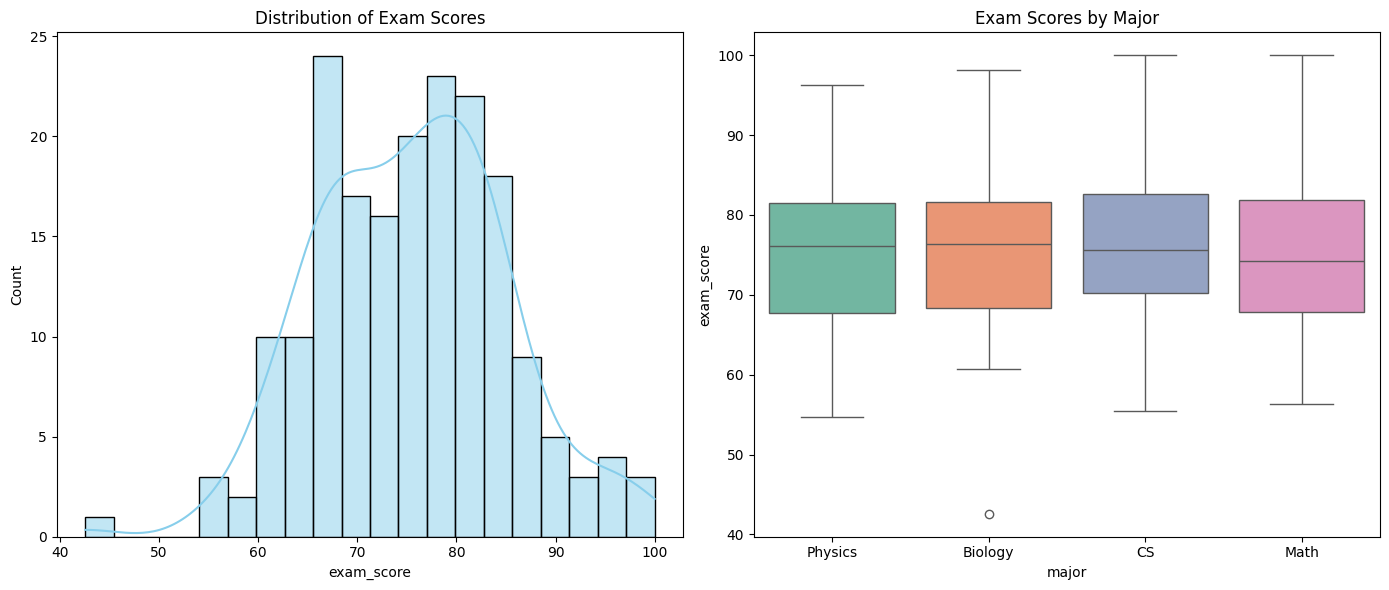

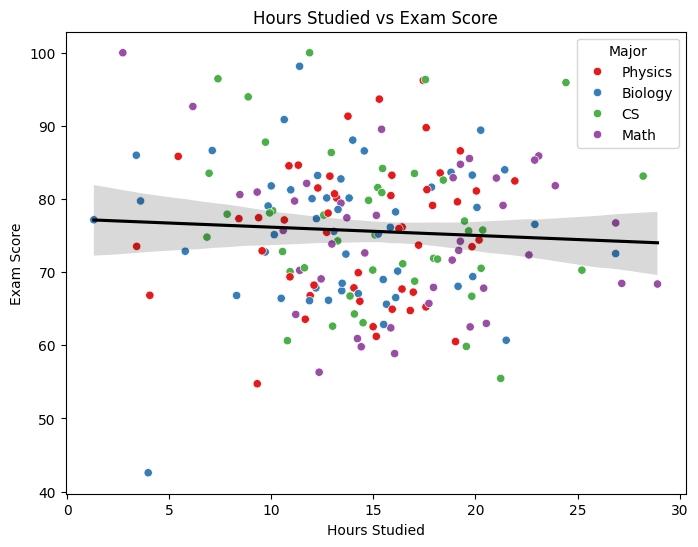

C:\Users\USER\AppData\Local\Temp\ipykernel_31044\2126577462.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='major', y='exam_score', data=df, estimator=np.mean, palette='Set3')
C:\Users\USER\AppData\Local\Temp\ipykernel_31044\2126577462.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_31044\2126577462.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='performance', y='exam_score', data=df, palette='Set1')


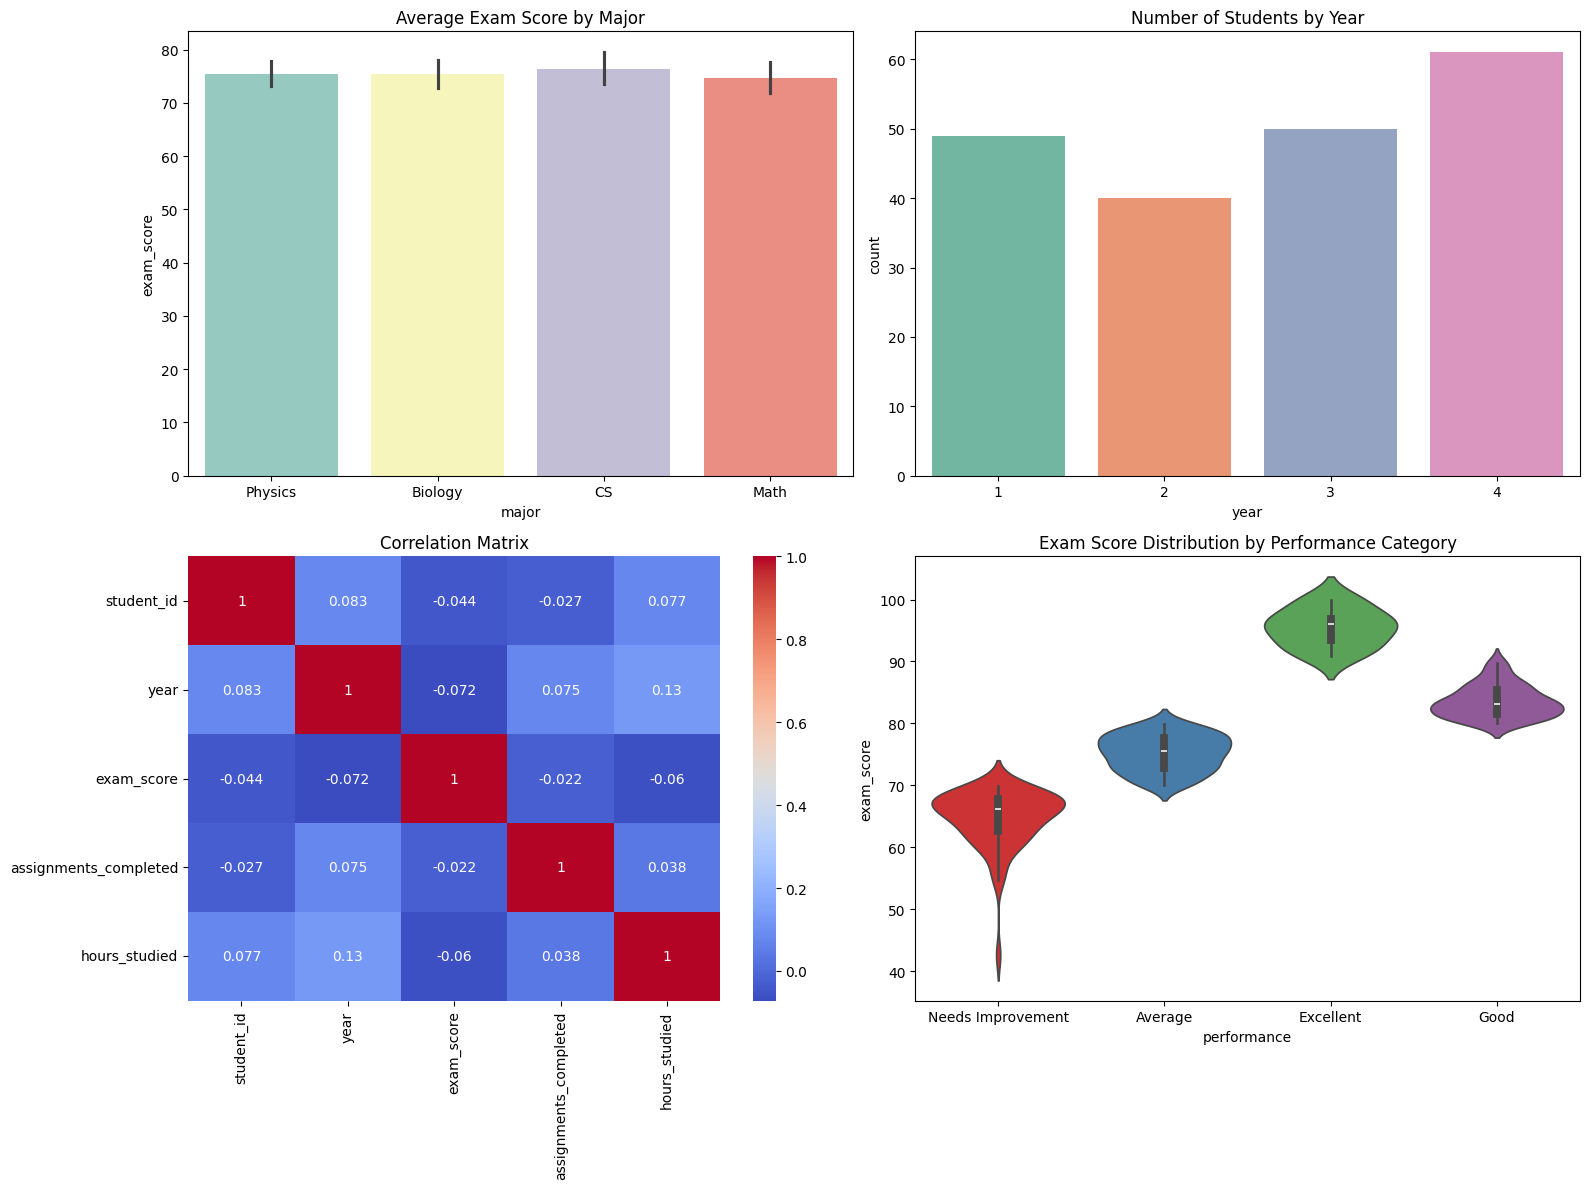

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score > 80:
        return 'Good'
    elif score > 70:
        return 'Average'
    else:
        return 'Needs Improvement'
    
df['performance'] = df['exam_score'].apply(categorize_performance)


#Task 1: Distribution Visualization
#i  Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Exam Scores')
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')
plt.title('Exam Scores by Major')
plt.tight_layout()
plt.show()

#Task 2: Relationship Visualisation
#Create a scatter plot of hours_studied vs exam_score
#Color points by major
#Add a regression line
#Include appropriate legends, titles, and axis labels
plt.figure(figsize=(8, 6))
sns.scatterplot(x='hours_studied', y='exam_score', hue='major', data=df, palette='Set1')
sns.regplot(x='hours_studied', y='exam_score', data=df, scatter=False, color='black')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')    
plt.legend(title='Major')
plt.show()

#Task 3: Advanced Dashboard
# Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# Adjust layout, add titles, and ensure readability

plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
sns.barplot(x='major', y='exam_score', data=df, estimator=np.mean, palette='Set3')
plt.title('Average Exam Score by Major')
plt.subplot(2, 2, 2)
sns.countplot(x='year', data=df, palette='Set2')
plt.title('Number of Students by Year')
plt.subplot(2, 2, 3)
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.subplot(2, 2, 4)
sns.violinplot(x='performance', y='exam_score', data=df, palette='Set1')
plt.title('Exam Score Distribution by Performance Category')
plt.tight_layout()
plt.show()


Excersise 7: Integration Challenge

0       937.397271
1       370.085023
2       418.424348
3       477.171887
4      1097.651683
          ...     
495     750.052567
496     408.682977
497     276.305018
498    1149.667906
499     780.543489
Name: CLV, Length: 500, dtype: float64
  age_group  num_customers    avg_income     avg_CLV      total_CLV
0     18-25             69  50505.697314  736.900315   50846.121747
1     26-35             78  48995.054923  709.160920   55314.551777
2     36-50            149  49376.830528  751.915669  112035.434720
3     51-70            204  49958.793339  753.359412  153685.320149
Top 10%
      age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6     38  58876.388563                  10          110.331527    0.166667   
9     40  48809.492879                  10          110.228581    0.166667   
19    41  21282.756976                   8          119.651218    0.333333   
24    38  53981.193911                   8          120.320786    0.333333   
57    64  459

C:\Users\USER\AppData\Local\Temp\ipykernel_31044\828702749.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='CLV', data=customers, estimator=np.mean, palette='Set2')


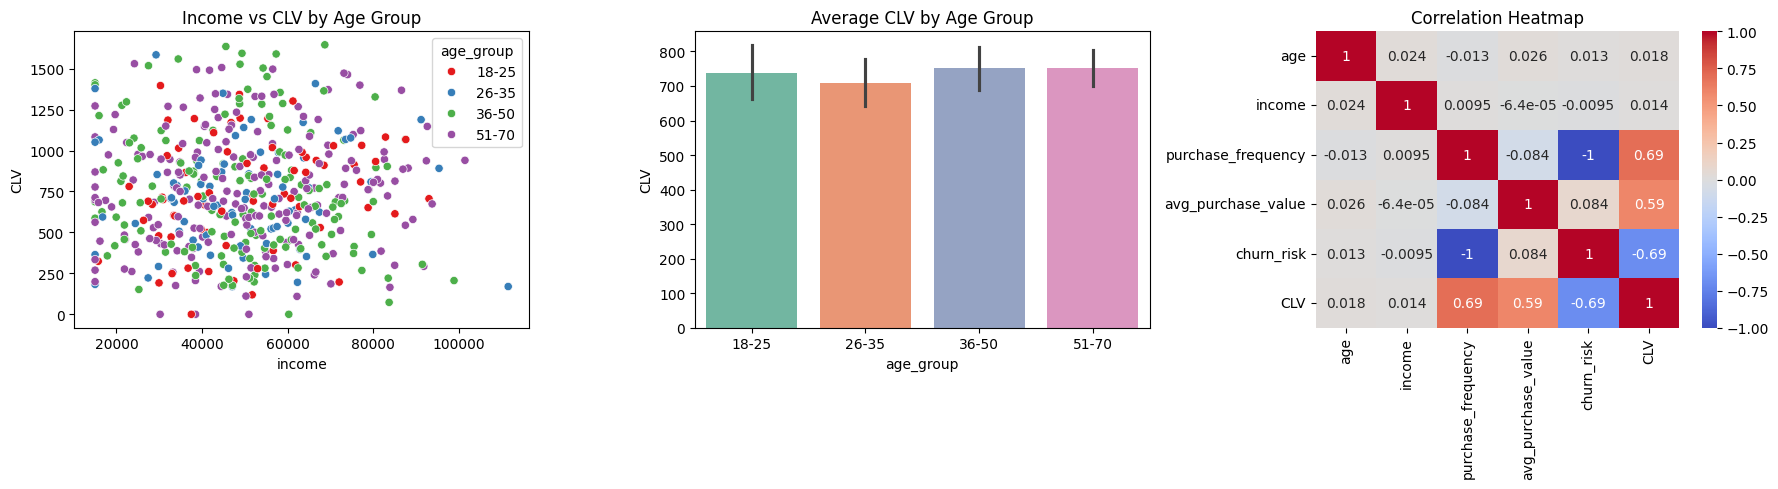

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

#i.  Calculate customer lifetime value (CLV)
#  CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#  where churn_risk = 1 - (purchase_frequency / max_frequency)

max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])
print(customers['CLV'])

#ii. Create age groups: 18-25, 26-35, 36-50, 51-70
#iii For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)
age_group_summary = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).reset_index()
print(age_group_summary)

#iv. Identify top 10% of customers by CLV
top_10_percent_threshold = customers['CLV'].quantile(0.9)
top_customers = customers[customers['CLV'] >= top_10_percent_threshold]
print('Top 10%\n',top_customers)

#v.  Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x='income', y='CLV', hue='age_group', data=customers, palette='Set1')
plt.title('Income vs CLV by Age Group')
plt.subplot(1, 3, 2)
sns.barplot(x='age_group', y='CLV', data=customers, estimator=np.mean, palette='Set2')
plt.title('Average CLV by Age Group')
plt.subplot(1, 3, 3)
sns.heatmap(customers.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#vi. 

Based on the data analysis there isn't much change necessary to the current approach the e-commerce company is taken. However special attention needs to be takwen with the 26-35 age group as they have the smallest CLV between all the age groups.